# DeepQBot vs Everyone

`agents.qtable_bot.QTableBot` learned to beat SmeshBot, but its 504-state
discretization makes its behavior visibly "blocky" / grid-like and likely
exploitable. `agents.deepq_bot.DeepQBot` keeps the same action space and reward
shaping but replaces the lookup table with a small PyTorch MLP over continuous
features (24-dim, including distance to each platform edge), trained with
standard DQN (replay buffer + target network).

This notebook trains a single `DeepQBot` instance for 1000 episodes, round-robin
against all 4 existing brains (`RandomBot`, `ChaserBot`, `SmeshBot`, and a frozen
`QTableBot` loaded from its trained checkpoint), and logs progress to MLflow every
100 episodes.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from tqdm.auto import tqdm

from smeshlite.core.match import Match, MatchConfig
from agents.random_bot import RandomBot
from agents.chaser_bot import ChaserBot
from agents.smesh_bot import SmeshBot
from agents.qtable_bot import QTableBot
from agents.doubledeepq_bot import DoubleDeepQBot

c:\Users\bonim\Documents\Uni\SmeshLite\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Agent design recap

See `agents/deepq_bot.py` for the full docstring. In short:

- **State** (24 continuous floats): `brain_context_to_obs()` (11 self + 11 opponent:
  position, velocity, damage, stocks, action, action_frame, facing, in_air, charge),
  plus 2 edge-distance features (`x - stage_platform_x1`, `stage_platform_x2 - x`),
  each divided by a fixed per-feature scale.
- **Actions** (8): same mapping as QTableBot — `NONE, LEFT, RIGHT, UP, ATTACK,
  LEFT+ATTACK, RIGHT+ATTACK, UP+ATTACK`.
- **Reward**: identical shaping to `QTableBot._reward` — `+dmg_scale * damage dealt`,
  `+ko_reward` for a KO, `-death_penalty` for losing a stock.
- **Learning**: DQN — a `policy_net`/`target_net` pair, a replay buffer, epsilon-greedy
  action selection, trained every `train_every` ticks. Because `think()` is never
  called again after the KO-causing tick, `new_episode(final_snapshot=...)` finalizes
  the pending transition with the match's final (damage, stocks) snapshot so the
  terminal KO/death reward isn't lost.


In [2]:
deepq = DoubleDeepQBot(device="cpu")
print("device:", deepq.device)

# Frozen baseline: trained Q-table, no further learning during DeepQBot's training.
qtable_opponent = QTableBot(q_table_path="agents/checkpoints/qtable_bot.json", epsilon=0.0, alpha=0.0)

OPPONENT_CYCLE = [RandomBot, ChaserBot, SmeshBot, lambda: qtable_opponent]
OPPONENT_NAMES = ["RandomBot", "ChaserBot", "SmeshBot", "QTableBot"]

N_EPISODES = 5000
LOG_EVERY = 100
EPSILON_START = 0.3
EPSILON_END = 0.02


def epsilon_for(episode: int) -> float:
    """Linear decay from EPSILON_START to EPSILON_END over N_EPISODES."""
    t = min(episode / N_EPISODES, 1.0)
    return EPSILON_START + (EPSILON_END - EPSILON_START) * t

device: cpu


## Training loop

Each episode: set `deepq.epsilon` from the decay schedule, pick the next opponent
from the round-robin cycle (`RandomBot -> ChaserBot -> SmeshBot -> QTableBot ->
repeat`), play a fresh `Match(MatchConfig(time_limit=1800))` to completion (DeepQBot
as P0), then finalize the episode with `deepq.new_episode(final_snapshot=...)` so the
terminal reward is credited. Every `LOG_EVERY` episodes, aggregate the trailing window
(overall and per opponent) and log it to MLflow as a metric step.

A 20-episode timing run took ~0.5s/episode, so 1000 episodes should take roughly
10 minutes on CPU (faster if CUDA is available).


In [3]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("doubledeepq_vs_all")

history = []
t0 = time.time()

with mlflow.start_run(run_name=f"deepq_{time.strftime('%Y%m%d_%H%M%S')}") as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "alpha": deepq.alpha,
        "gamma": deepq.gamma,
        "dmg_scale": deepq.dmg_scale,
        "ko_reward": deepq.ko_reward,
        "death_penalty": deepq.death_penalty,
        "time_penalty": deepq.time_penalty,
        "train_every": deepq.train_every,
        "batch_size": deepq.batch_size,
        "target_update_every": deepq.target_update_every,
        "n_actions": DoubleDeepQBot.N_ACTIONS,
        "obs_dim": DoubleDeepQBot.OBS_DIM,
        "n_episodes": N_EPISODES,
        "log_every": LOG_EVERY,
        "epsilon_start": EPSILON_START,
        "epsilon_end": EPSILON_END,
        "opponent_cycle": ", ".join(OPPONENT_NAMES),
        "device": str(deepq.device),
    })

    pbar = tqdm(range(1, N_EPISODES + 1), desc="DoubleDeepQBot", unit="ep")
    for episode in pbar:
        deepq.epsilon = epsilon_for(episode)
        opponent = OPPONENT_CYCLE[(episode - 1) % len(OPPONENT_CYCLE)]()
        opponent_name = OPPONENT_NAMES[(episode - 1) % len(OPPONENT_NAMES)]

        m = Match(MatchConfig(time_limit=1800))
        m.reset(n_players=2)
        m.set_player_brain(0, deepq)
        m.set_player_brain(1, opponent)

        while not m.done:
            m.tick()

        final_snapshot = (
            m.characters[0].damage_pct, m.characters[0].stocks,
            m.characters[1].damage_pct, m.characters[1].stocks,
        )
        ep_reward = deepq.new_episode(final_snapshot=final_snapshot)

        history.append({
            "episode": episode,
            "opponent": opponent_name,
            "winner": m.winner,
            "frames": m.frame,
            "episode_reward": ep_reward,
            "epsilon": deepq.epsilon,
            "last_loss": deepq.last_loss,
            "buffer_len": len(deepq.replay_buffer),
        })

        if episode % LOG_EVERY == 0:
            recent = pd.DataFrame(history[-LOG_EVERY:])
            metrics = {
                "win_rate": (recent["winner"] == 0).mean(),
                "avg_reward": recent["episode_reward"].mean(),
                "avg_loss": recent["last_loss"].dropna().mean(),
                "epsilon": deepq.epsilon,
                "buffer_len": len(deepq.replay_buffer),
            }
            for opp_name, group in recent.groupby("opponent"):
                metrics[f"win_rate_{opp_name}"] = (group["winner"] == 0).mean()
                metrics[f"avg_reward_{opp_name}"] = group["episode_reward"].mean()
            mlflow.log_metrics(metrics, step=episode)
            pbar.set_postfix(win_rate=f"{metrics['win_rate']:.2f}", avg_reward=f"{metrics['avg_reward']:+.2f}")
            tqdm.write(f"episode {episode:5d}: win_rate={metrics['win_rate']:.2f} avg_reward={metrics['avg_reward']:+.3f} avg_loss={metrics['avg_loss']:.4f}")

print(f"done in {time.time() - t0:.1f}s")
df = pd.DataFrame(history)
df.tail()

DoubleDeepQBot:   2%|▏         | 100/5000 [00:36<1:44:42,  1.28s/ep, avg_reward=-0.19, win_rate=0.31]

episode   100: win_rate=0.31 avg_reward=-0.188 avg_loss=0.0075


DoubleDeepQBot:   4%|▍         | 200/5000 [01:15<1:20:14,  1.00s/ep, avg_reward=-0.19, win_rate=0.35]

episode   200: win_rate=0.35 avg_reward=-0.191 avg_loss=0.0056


DoubleDeepQBot:   6%|▌         | 300/5000 [01:45<1:13:32,  1.07ep/s, avg_reward=-1.16, win_rate=0.26]

...

DoubleDeepQBot:  98%|█████████▊| 4900/5000 [36:05<01:51,  1.11s/ep, avg_reward=-0.53, win_rate=0.38]

episode  4900: win_rate=0.38 avg_reward=-0.525 avg_loss=0.0071


DoubleDeepQBot: 100%|██████████| 5000/5000 [36:58<00:00,  2.25ep/s, avg_reward=+0.11, win_rate=0.50]


episode  5000: win_rate=0.50 avg_reward=+0.113 avg_loss=0.0045
🏃 View run deepq_20260615_160043 at: http://localhost:5000/#/experiments/7/runs/ee132d2d58694c1f8d62e0c0bfda3ea9
🧪 View experiment at: http://localhost:5000/#/experiments/7
done in 2218.8s


,episode,opponent,winner,frames,episode_reward,epsilon,last_loss,buffer_len
4995,4996,QTableBot,0.0,1800,1.1275,0.020224,0.001128,50000
4996,4997,RandomBot,0.0,1800,0.0000,0.020168,0.004593,50000
4997,4998,ChaserBot,0.0,330,3.0000,0.020112,0.001405,50000
4998,4999,SmeshBot,1.0,1800,-1.0000,0.020056,0.001874,50000
4999,5000,QTableBot,0.0,1800,0.0000,0.020000,0.003568,50000


## Results


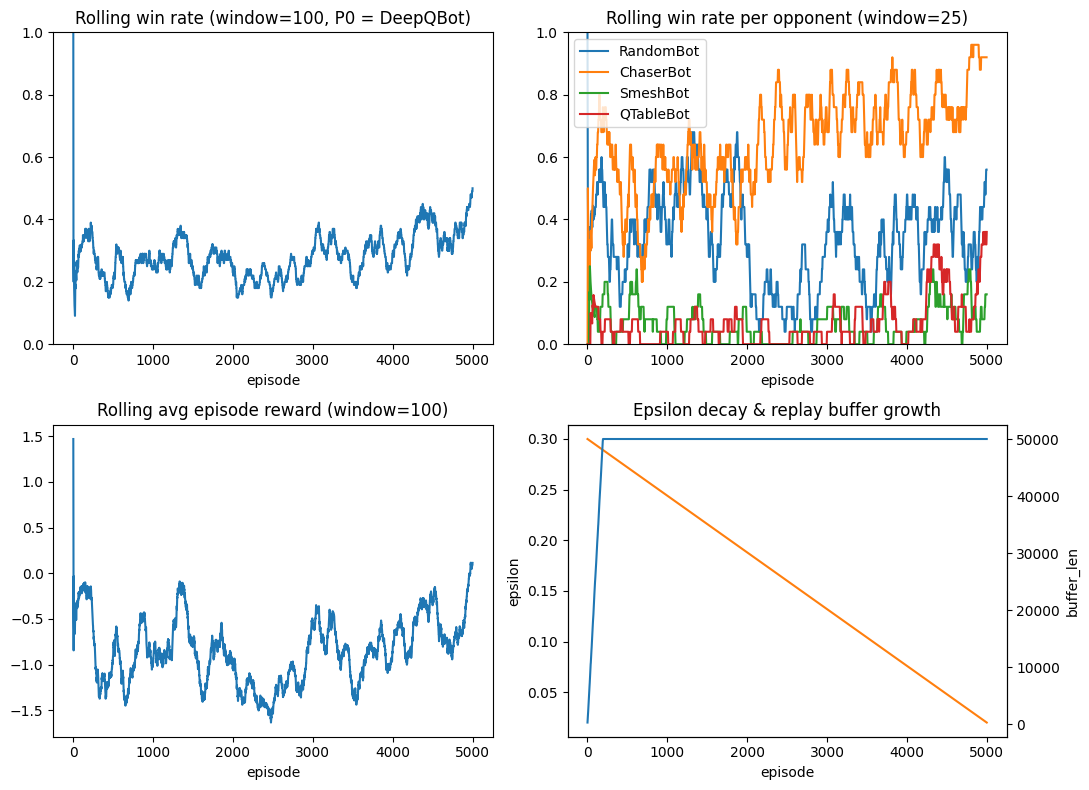

In [4]:
win_rolling = df["winner"].eq(0).rolling(100, min_periods=1).mean()
reward_rolling = df["episode_reward"].rolling(100, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df["episode"], win_rolling)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Rolling win rate (window=100, P0 = DeepQBot)")
axes[0, 0].set_xlabel("episode")

for opp_name in OPPONENT_NAMES:
    mask = df["opponent"] == opp_name
    opp_win_rolling = df.loc[mask, "winner"].eq(0).rolling(25, min_periods=1).mean()
    axes[0, 1].plot(df.loc[mask, "episode"], opp_win_rolling, label=opp_name)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Rolling win rate per opponent (window=25)")
axes[0, 1].set_xlabel("episode")
axes[0, 1].legend()

axes[1, 0].plot(df["episode"], reward_rolling)
axes[1, 0].set_title("Rolling avg episode reward (window=100)")
axes[1, 0].set_xlabel("episode")

ax_eps = axes[1, 1]
ax_eps.plot(df["episode"], df["epsilon"], color="tab:orange", label="epsilon")
ax_eps.set_ylabel("epsilon")
ax_eps.set_xlabel("episode")
ax_buf = ax_eps.twinx()
ax_buf.plot(df["episode"], df["buffer_len"], color="tab:blue", label="buffer_len")
ax_buf.set_ylabel("buffer_len")
axes[1, 1].set_title("Epsilon decay & replay buffer growth")

fig.tight_layout()


## Episode-level diagnostics (from `df`, not MLflow)

Everything above this point — including the per-opponent breakdown further down —
comes from MLflow's 100-episode-window aggregates (`win_rate`, `avg_reward`,
`avg_loss`, and their per-opponent variants). `df`, built in the training loop
above, has one row per episode (2000 rows: `episode, opponent, winner, frames,
episode_reward, epsilon, last_loss, buffer_len`) and never leaves this notebook's
memory — those aggregates are computed *from* it but throw away everything within
each window. The cells below work directly off `df` to ask a few questions the
aggregates can't answer:

- Does `episode_reward` actually track `winner`, episode by episode?
- Is the climb in win rate smooth, or streaky?
- Are matches ending in KOs faster as training progresses, or running to the time
  limit more?
- What does the *raw* per-episode loss look like underneath the smoothed MLflow
  curve?

No MLflow round-trip, no kernel restart — just `df` from the training cell above.

### Does episode reward actually predict winning?

You raised this earlier: if reward and win rate can move independently, the reward
function might not be measuring what we actually care about. MLflow's `avg_reward`
and `win_rate` are both 100-episode aggregates, so a correlation between *those two
curves* says nothing about whether reward predicts the outcome *within* an episode.
Here we correlate `episode_reward` with `winner` directly, per opponent and overall,
and look at the actual point cloud rather than two separate trend lines.

ChaserBot    0.850705
QTableBot    0.610333
RandomBot    0.816583
SmeshBot     0.560881
Name: corr(episode_reward, win), dtype: float64

overall: 0.828


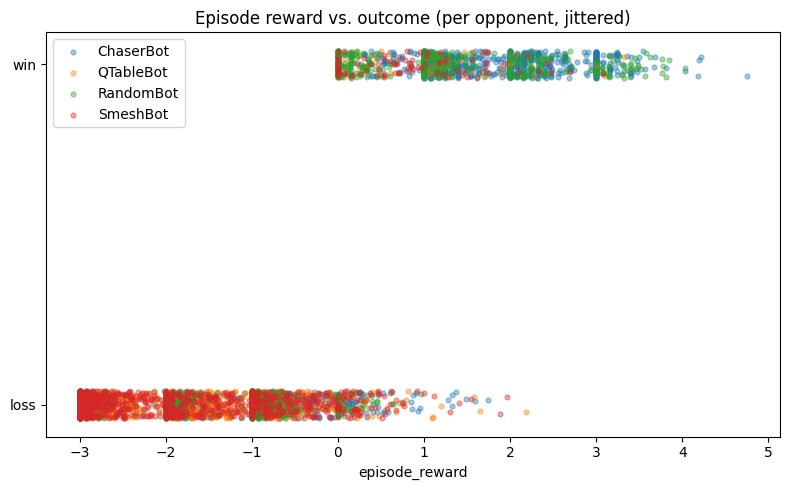

In [5]:
win = df["winner"].eq(0).astype(float)

corr_by_opp = pd.Series({
    opp: g["episode_reward"].corr(win.loc[g.index])
    for opp, g in df.groupby("opponent")
}, name="corr(episode_reward, win)")
print(corr_by_opp)
print(f"\noverall: {df['episode_reward'].corr(win):.3f}")

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 5))
for opp, g in df.groupby("opponent"):
    jitter = rng.uniform(-0.04, 0.04, size=len(g))
    ax.scatter(g["episode_reward"], win.loc[g.index] + jitter, alpha=0.4, s=12, label=opp)

ax.set_xlabel("episode_reward")
ax.set_yticks([0, 1])
ax.set_yticklabels(["loss", "win"])
ax.set_title("Episode reward vs. outcome (per opponent, jittered)")
ax.legend()
fig.tight_layout()

### Win/loss streaks: a smooth climb, or a streaky one?

A 100-episode rolling win rate can look smooth even when the underlying sequence is
bursty — a long run of losses followed by a long run of wins averages out to the
same curve as alternating wins and losses, but the two describe very different
training dynamics (the former looks like the policy oscillating between strategies;
the latter looks like steady, episode-by-episode improvement). Run-length-encoding
`df["winner"]` gives the actual streak-length distribution, independent of any
window size.

longest win streak:  6 episodes
longest loss streak: 27 episodes
mean win streak:  1.35
mean loss streak: 3.42


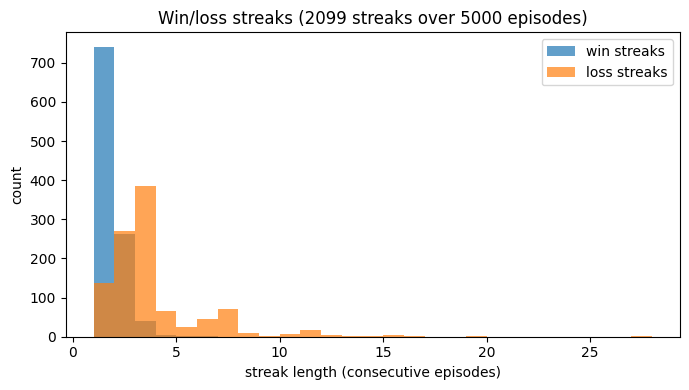

In [6]:
is_win = df["winner"].eq(0).to_numpy()

runs = []
cur_val, cur_len = is_win[0], 1
for v in is_win[1:]:
    if v == cur_val:
        cur_len += 1
    else:
        runs.append((cur_val, cur_len))
        cur_val, cur_len = v, 1
runs.append((cur_val, cur_len))
streaks = pd.DataFrame(runs, columns=["is_win", "length"])

fig, ax = plt.subplots(figsize=(7, 4))
bins = range(1, streaks["length"].max() + 2)
ax.hist(streaks.loc[streaks["is_win"], "length"], bins=bins, alpha=0.7, label="win streaks")
ax.hist(streaks.loc[~streaks["is_win"], "length"], bins=bins, alpha=0.7, label="loss streaks")
ax.set_xlabel("streak length (consecutive episodes)")
ax.set_ylabel("count")
ax.set_title(f"Win/loss streaks ({len(streaks)} streaks over {len(df)} episodes)")
ax.legend()
fig.tight_layout()

print(f"longest win streak:  {streaks.loc[streaks['is_win'], 'length'].max()} episodes")
print(f"longest loss streak: {streaks.loc[~streaks['is_win'], 'length'].max()} episodes")
print(f"mean win streak:  {streaks.loc[streaks['is_win'], 'length'].mean():.2f}")
print(f"mean loss streak: {streaks.loc[~streaks['is_win'], 'length'].mean():.2f}")

### Match length: are fights ending in KOs faster, or going to the time limit more?

`frames` never makes it into MLflow at all. A bot that's actually getting better
should start closing out matches via KOs (shorter `frames`) rather than running to
the `time_limit=1800` cap — and the win/loss split per opponent shows whether wins
and losses *look* different in duration (quick KOs vs. drawn-out time-limit
decisions). The second plot tracks the trend over training, per opponent — useful
context for the parked `doubledeepqcowardbot` idea too, where survival time would
become the actual objective rather than an incidental artifact.

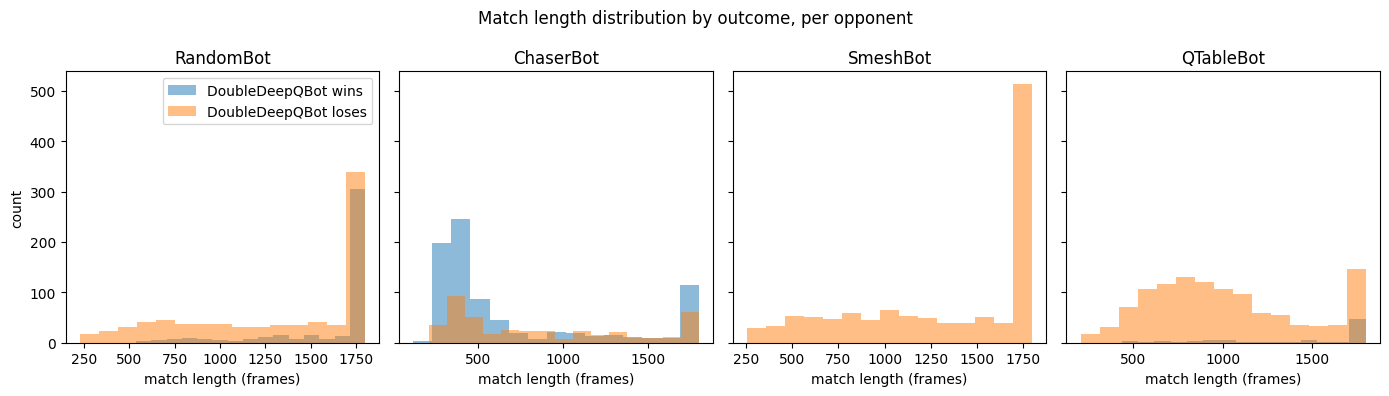

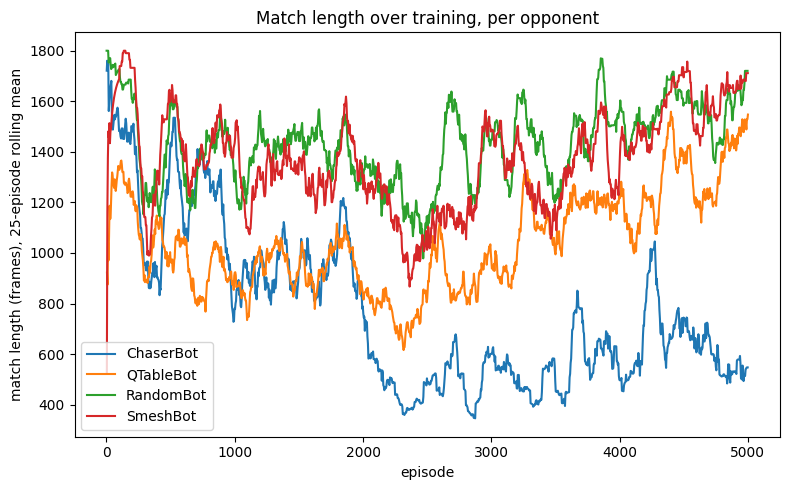

In [7]:
fig, axes = plt.subplots(1, len(OPPONENT_NAMES), figsize=(14, 4), sharey=True)
for ax, opp in zip(axes, OPPONENT_NAMES):
    sub = df[df["opponent"] == opp]
    wins = sub[sub["winner"] == 0]
    losses = sub[sub["winner"] != 0]
    ax.hist(wins["frames"], bins=15, alpha=0.5, label="DoubleDeepQBot wins")
    ax.hist(losses["frames"], bins=15, alpha=0.5, label="DoubleDeepQBot loses")
    ax.set_title(opp)
    ax.set_xlabel("match length (frames)")
axes[0].set_ylabel("count")
axes[0].legend()
fig.suptitle("Match length distribution by outcome, per opponent")
fig.tight_layout()

fig, ax = plt.subplots(figsize=(8, 5))
for opp, g in df.groupby("opponent"):
    g = g.sort_values("episode")
    ax.plot(g["episode"], g["frames"].rolling(25, min_periods=1).mean(), label=opp)
ax.set_xlabel("episode")
ax.set_ylabel("match length (frames), 25-episode rolling mean")
ax.set_title("Match length over training, per opponent")
ax.legend()
fig.tight_layout()

### Raw per-episode loss vs. the smoothed MLflow curve

MLflow's `avg_loss` is the mean over each 100-episode window, which can hide whether
"the loss is growing" is a real upward trend or just high-variance noise around a
roughly flat (or even declining) mean. `df["last_loss"]` is the loss from the last
`_learn()` call in each episode — plotting it raw (log scale, since it spans orders
of magnitude between early and late training) with a rolling-mean overlay shows the
actual noise underneath the MLflow curve. The right panel checks whether loss tracks
replay-buffer fill (e.g. spikes while the buffer is still small and the sample
distribution is shifting fast, settling down once it's full).

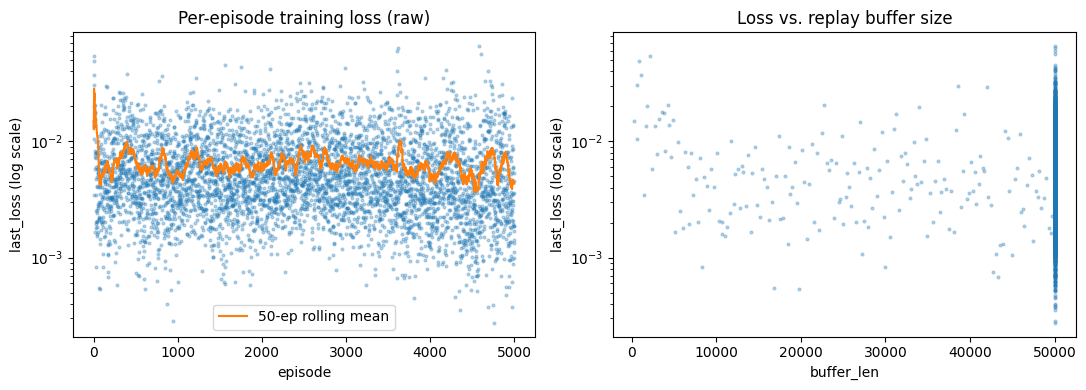

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(df["episode"], df["last_loss"], s=4, alpha=0.3)
axes[0].plot(df["episode"], df["last_loss"].rolling(50, min_periods=1).mean(), color="C1", label="50-ep rolling mean")
axes[0].set_yscale("log")
axes[0].set_xlabel("episode")
axes[0].set_ylabel("last_loss (log scale)")
axes[0].set_title("Per-episode training loss (raw)")
axes[0].legend()

axes[1].scatter(df["buffer_len"], df["last_loss"], s=4, alpha=0.3)
axes[1].set_yscale("log")
axes[1].set_xlabel("buffer_len")
axes[1].set_ylabel("last_loss (log scale)")
axes[1].set_title("Loss vs. replay buffer size")

fig.tight_layout()

In [9]:
checkpoint_path = "agents/checkpoints/doubledeepq_bot.pt"
deepq.save(checkpoint_path)

with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact(checkpoint_path)

print(f"Saved policy network ({deepq.step_count} steps trained) to {checkpoint_path}")


🏃 View run deepq_20260615_160043 at: http://localhost:5000/#/experiments/7/runs/ee132d2d58694c1f8d62e0c0bfda3ea9
🧪 View experiment at: http://localhost:5000/#/experiments/7
Saved policy network (963118 steps trained) to agents/checkpoints/doubledeepq_bot.pt


## Per-opponent breakdown: where are the wins (and losses) coming from?

Every win-rate curve so far — v1, the dueling-only run, v2 (dueling + 47-dim features), and this Double DQN run — has been a single number averaged across a 4-opponent round-robin (RandomBot, ChaserBot, SmeshBot, frozen QTableBot). The training loop already logs `win_rate_<opponent>` per 100-episode window to MLflow; it has just never been plotted. Pulling it for this run and the v2 run it's meant to improve on:


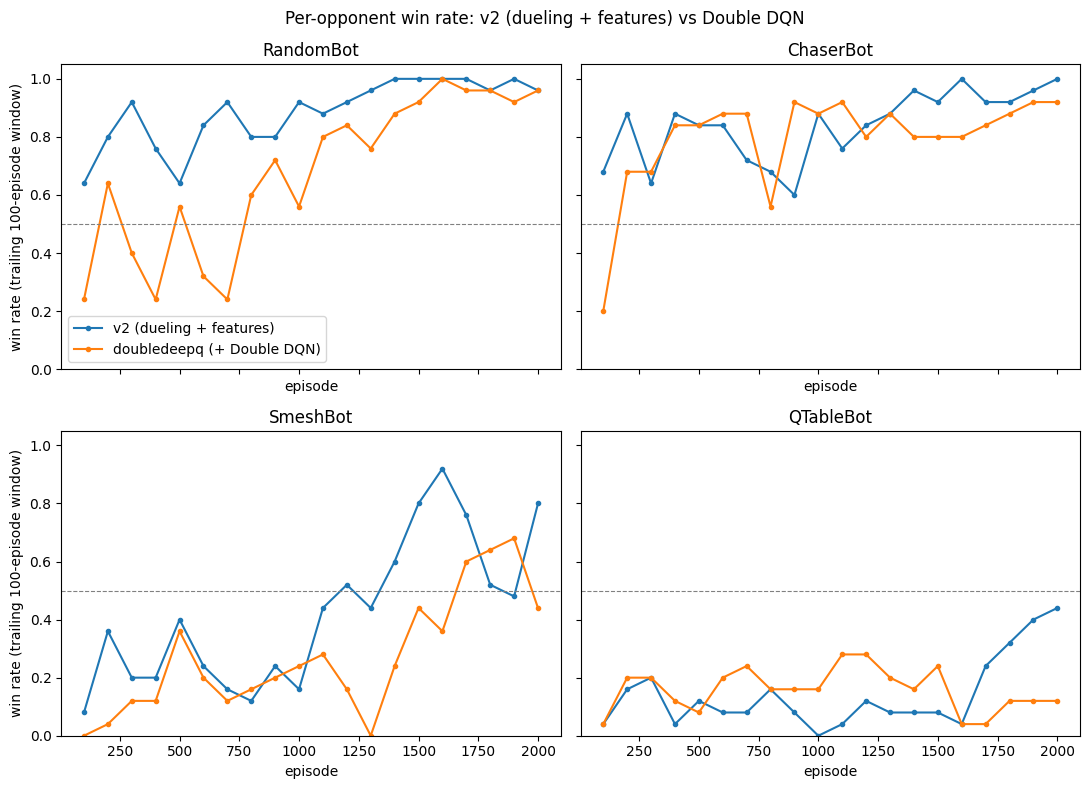

In [10]:
from mlflow.tracking import MlflowClient

_client = MlflowClient()

# The two completed 2000-episode round-robin runs being compared:
#  - v2: dueling head + 47-dim feature encoding (agents/deepq_bot_v2.py)
#  - this run: v2's architecture + Double DQN target (agents/doubledeepq_bot.py)
_COMPARE_RUNS = {
    "v2 (dueling + features)": "5fddb9db769d443fb0dae2534ff36875",
    "doubledeepq (+ Double DQN)": "eff85606f5d3468987a22768e7727948",
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, opp in zip(axes.flat, OPPONENT_NAMES):
    for label, rid in _COMPARE_RUNS.items():
        hist = sorted(_client.get_metric_history(rid, f"win_rate_{opp}"), key=lambda m: m.step)
        ax.plot([m.step for m in hist], [m.value for m in hist], marker="o", markersize=3, label=label)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(opp)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("episode")

axes[0, 0].set_ylabel("win rate (trailing 100-episode window)")
axes[1, 0].set_ylabel("win rate (trailing 100-episode window)")
axes[0, 0].legend()
fig.suptitle("Per-opponent win rate: v2 (dueling + features) vs Double DQN")
fig.tight_layout()


### Findings

**RandomBot and ChaserBot are essentially solved in both runs** — both climb to ~0.8-1.0 win rate by the second half of training, with v2 finishing marginally higher (ChaserBot 1.00 vs 0.92, RandomBot 0.96 vs 0.96). These two opponents are not where the two runs differ.

**SmeshBot and QTableBot are where the runs diverge — and where the aggregate gap (v2: 0.80 at ep2000 vs. Double DQN: 0.61) actually comes from:**

- *SmeshBot*: v2 reaches a noisy 0.48-0.92 band in the back half, ending at 0.80. Double DQN climbs more slowly and ends at 0.44 — roughly half of v2's.
- *QTableBot*: this is the starkest difference. v2 sits in a 0.00-0.24 band (mostly ≤0.16) for the **first 1600 episodes** — QTableBot looks essentially unbeatable for 80% of training — then breaks out to 0.24 → 0.32 → 0.40 → 0.44 over the final 400 episodes. **Double DQN never reproduces this breakout.** It stays in a 0.04-0.28 band for the *entire* run, and its back half is actually *worse* than its middle: it peaks at 0.28 around ep1100-1200, declines to 0.04 by ep1600-1700, and recovers only to 0.12 by ep2000 — while RandomBot, ChaserBot, and SmeshBot were all *improving* over that same window.

### What this suggests

The "Double DQN underperforms v2" finding from the aggregate numbers isn't a uniform regression — it's concentrated almost entirely in the QTableBot matchup. v2's late QTableBot breakout (ep1600→2000) looks like exactly the kind of "found a counter-strategy" event we'd been hoping for; this Double DQN run simply hasn't found it.

One speculative read: overestimation bias can act as a useful exploration signal — "this looks better than it probably is, worth trying again." Double DQN's entire point is to remove that. If v2's QTableBot breakout was partly driven by an overoptimistic Q-value that kept the network revisiting a strategy long enough to discover it actually worked, Double DQN's more conservative estimates might be *correctly* avoiding that strategy right up until the point it would have paid off — i.e. the bias correction could be trading away a useful "long-shot persistence" effect. That's one run each, though, so this is a hypothesis, not a conclusion.

The QTableBot decline during ep1100→1700 (while the other three opponents keep improving) also echoes the original v1 diagnosis: shared-parameter interference, where gradient steps that help against the dominant/easy opponents can degrade the policy in the specific state-regions that matter against the hard one.

### Open threads this points at
- More seeds before concluding Double DQN is better or worse than v2 — a single-run comparison can't separate architecture effects from this much run-to-run variance.
- The net-damage-differential reward discussed above might matter most here: QTableBot is the one opponent running a real (if discretized) policy rather than a fixed script, so reward shaping that better reflects "who's actually ahead" could matter more in this matchup specifically.
- Prioritized replay — QTableBot transitions are ~25% of the buffer by construction but may be the highest-value ones to prioritize.
- `doubledeepqcowardbot` (parked earlier) faces the same opponent pool — worth checking its QTableBot matchup specifically once it exists.


## Post-mortem (updated)

The original post-mortem for this notebook series described `DeepQBot` v1's collapse: Q-values converged to ≈constant across all states/actions, with V(s) crowding out A(s,a) under a sparse reward. That diagnosis held, and the fixes built on it since then are:

1. **Dueling head** (`agents/deepq_bot_v2.py`): split `value_head`/`advantage_head` so A(s,a) gets dedicated capacity. Aggregate win rate moved from a flat ~0.5 oscillation to a real upward trend.
2. **47-dim feature engineering** (`agents/deepq_bot_v2.py`): one-hot actions, unit-direction + magnitude decomposition, closing speed, edge distances, invincibility, etc. Aggregate win rate reached 0.80 by ep2000, up from the dueling-only run's ~0.5 oscillation.
3. **Double DQN target** (`agents/doubledeepq_bot.py`, this notebook): decouple action selection (`policy_net`) from evaluation (`target_net`) to reduce overestimation bias. Aggregate win rate reached 0.61 by ep2000 — lower than (2).

The per-opponent breakdown above is the important result. Steps (1) and (2) solved RandomBot and ChaserBot outright (both runs: ~0.9-1.0) and made real progress on SmeshBot and QTableBot. **QTableBot remains the open problem**: v2 spent 80% of training at ≤0.24 against it before a late breakout to 0.44 in the final 400 episodes; Double DQN never broke out, ending at 0.12 and actually *declining* over its back half while the other three matchups kept improving.

### Next steps
- Net-damage-differential reward (`reward += (dmg_dealt - dmg_taken) * dmg_scale`) — addresses the asymmetry where taking damage is invisible to the reward until a full stock is lost. QTableBot is the matchup most likely to benefit, since it's the one opponent capable of punishing recklessness.
- Possible shared `agents/_reward.py::compute_reward()` extraction, since this reward shape is now duplicated across QTableBot, DeepQBot v1/v2, and DoubleDeepQBot.
- More seeds per configuration before drawing conclusions about Double DQN vs. v2 — the QTableBot gap could be architecture or could be variance.
- Prioritized experience replay, network capacity (`hidden2` has been 8 since v1), and longer runs all remain untried levers for the QTableBot matchup specifically.
- `doubledeepqcowardbot` (survival-focused reward/behavior) — parked for later.
